**ECE 447: Data Analysis and Machine Learning for Engineers**

# Assignment 3 - Problem 2
**Regression: Linear Regression**

In [19]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [20]:
#### A3-P2 a) Prior to starting the visualization or analysis, explain—based on your intuition,
# what you expect to observe in the data (for example, comment on the relationship between goals
# and the input features).

In [21]:
# paths
path = "data"
nhl_path = os.path.join(path, "nhl_players.csv")

# load
df = pd.read_csv(nhl_path)
df.head()

,season,player_id,firstName,lastName,timeOnIce,assists,goals,shots,penaltyMinutes
0,20002001,8444894,Greg,Adams,51806,12,11,66,10
1,20002001,8444919,Tommy,Albelin,96465,19,1,69,22
2,20002001,8445000,Dave,Andreychuk,53248,13,20,119,32
3,20002001,8445176,Donald,Audette,90473,45,34,225,76
4,20002001,8445266,Murray,Baron,95471,8,3,56,63


In [22]:
#### A3-P2 a) ans: it depends on the student.

#### A3-P2 b) Visualize and plot scatter matrix between all features (suggestion: use \texttt{scatter\_matrix} from \texttt{plotly}).

df_used = df.drop(columns=["season", "player_id", "firstName", "lastName"])
fig = px.scatter_matrix(df_used, dimensions = ['timeOnIce', 'assists', 'goals', 'shots', 'penaltyMinutes'])
fig.update_layout(font=dict(size=9))
fig.update_layout(width = 800, height = 800)
fig.show()

# first impression, there is positive correlation (with penalityMin is low).

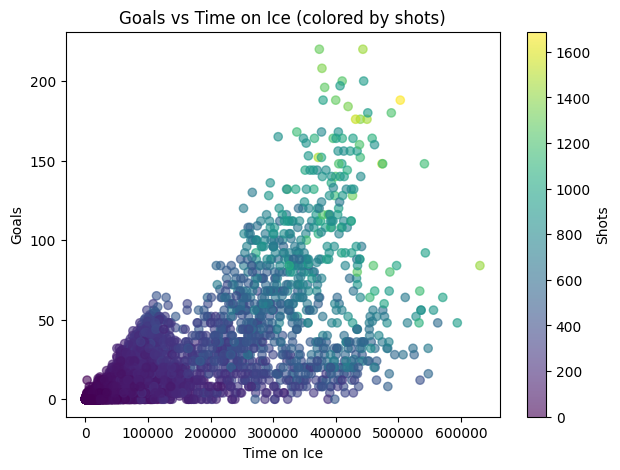

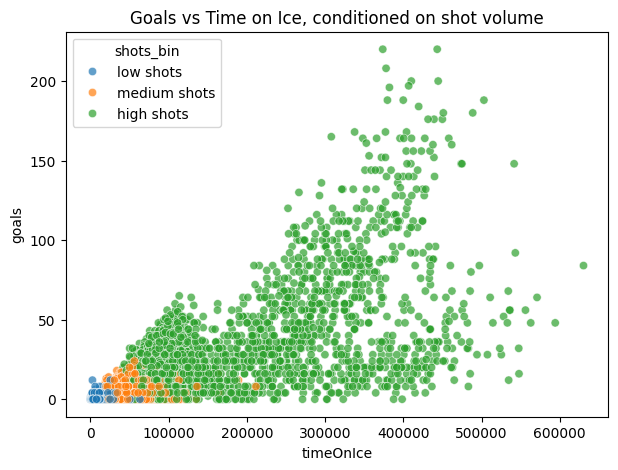

In [23]:
#### A3-P2 c,d) Visualize a scatter matrix of all features
# (suggestion: use scatter_matrix from plotly).
# Comment on the key correlations you observe.

plt.figure(figsize=(7, 5))
sc = plt.scatter(
    df["timeOnIce"],
    df["goals"],
    c=df["shots"],
    alpha=0.6
)
plt.xlabel("Time on Ice")
plt.ylabel("Goals")
plt.colorbar(sc, label="Shots")
plt.title("Goals vs Time on Ice (colored by shots)")
plt.show()

df["shots_bin"] = pd.qcut(df["shots"], q=3, labels=["low shots", "medium shots", "high shots"])

### with low/medium/high category
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="timeOnIce",
    y="goals",
    hue="shots_bin",
    alpha=0.7
)
plt.title("Goals vs Time on Ice, conditioned on shot volume")
plt.show()

# condition on shots, there variance (range) of # goals to time on ice is high.
# it's not that correled anymore.
# you can see in the second figure, for high shots, the relation between goals and timeonice highly varies.

In [24]:
#### A3-P2 e) 

y_df = df["goals"]

# create the feature matrix.
feature_cols = [
    "shots",
    "timeOnIce",
    "assists",
    "penaltyMinutes"
]
X_df = df[feature_cols]

print("X_df shape:", X_df.shape)
print("y_df shape:", y_df.shape)

print(X_df.isna().sum())
print(y_df.isna().sum())

#### A3-P2 f) dependts on students' reason. timeonIce +, assist +, panaltyMinutes +?

X_df shape: (16787, 4)
y_df shape: (16787,)
shots             0
timeOnIce         0
assists           0
penaltyMinutes    0
dtype: int64
0


In [25]:
#### A3-P2 g) Construct the target y and the matrix X, report their shapes,
# and split the data into training and test sets (hint: use train_test_split from sklearn.model_selection).
 
X = X_df.to_numpy()
X = np.concatenate([X, np.ones((X.shape[0], 1))], axis=1)
y = y_df.to_numpy()
y = y.reshape(y.shape[0], 1)
print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=8
)
print("X_train.shape", X_train.shape, "y_train", y_train.shape)
print("X_test.shape", X_test.shape, "y_test", y_test.shape)

(16787, 5) (16787, 1)
X_train.shape (13429, 5) y_train (13429, 1)
X_test.shape (3358, 5) y_test (3358, 1)


In [26]:
#### A3-P2 h, i, j, k) 

### Rank of X and the LS solution, and predictions
# it's full rank; so the LS solution exists uniquely

rank = np.linalg.matrix_rank(X_train)
print("rank of X is", rank)

def do_ls(X, y):
    XTX = np.dot(X.T, X)
    print("XTX.shape", XTX.shape)

    XTy = np.dot(X.T, y)
    print("XTy.shape", XTy.shape)

    theta_ls = np.dot(np.linalg.inv(XTX),XTy)
    return theta_ls

theta_ls = do_ls(X_train, y_train)

print("For features")
print(feature_cols)
print("Estimated theta is")
print(theta_ls)

## do prediction
y_pred_ls_train = np.dot(X_train, theta_ls)
print("Train R²:", r2_score(y_train, y_pred_ls_train))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_ls_train)))

y_pred_ls = np.dot(X_test, theta_ls)
print("R²:", r2_score(y_test, y_pred_ls))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ls)))

# positive means its increase will result in prediction of an increased goal,
# and negative means ins increase will result in prediction of a decreased goal.

rank of X is 5
XTX.shape (5, 5)
XTy.shape (5, 1)
For features
['shots', 'timeOnIce', 'assists', 'penaltyMinutes']
Estimated theta is
[[ 1.34793549e-01]
 [-1.22074543e-04]
 [ 1.70989835e-01]
 [ 4.82222451e-03]
 [ 2.13219027e-01]]
Train R²: 0.8591197209121032
Train RMSE: 6.661033251065594
R²: 0.8563590907322861
RMSE: 6.448206256557503


Text(0, 0.5, 'y test prediction')

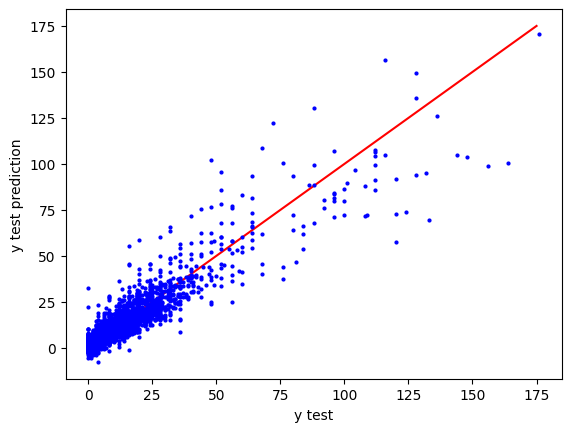

In [27]:
#### A3-P2 l) 

plt.figure()
t = np.linspace(0, 175, 175)
plt.plot(t, t, color="red")
plt.plot(y_test[:,0], y_pred_ls[:,0], "o", color="blue", markersize=2)
plt.xlabel("y test")
plt.ylabel("y test prediction")

# The gt vs prediction on test.



In [28]:
#### A3-P2 m) 

### Using LinearRegression, and predictions

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_linreg_train = model.predict(X_train)
print("Train R²:", r2_score(y_train, y_pred_linreg_train))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_linreg_train)))

y_pred_linreg = model.predict(X_test)
print("R²:", r2_score(y_test, y_pred_linreg))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_linreg)))



Train R²: 0.8591197209121032
Train RMSE: 6.661033251065594
R²: 0.8563590907322904
RMSE: 6.4482062565574045


Text(0, 0.5, 'y test prediction')

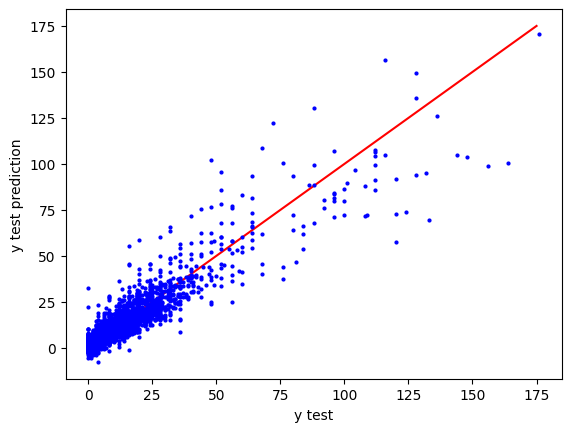

In [29]:
plt.figure()
t = np.linspace(0, 175, 175)
plt.plot(t, t, color="red")
plt.plot(y_test[:,0], y_pred_linreg[:,0], "o", color="blue", markersize=2)
plt.xlabel("y test")
plt.ylabel("y test prediction")

# The gt vs prediction on test.

